# Price per Square Meter and Location Effects


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Create new column 'price_per_m2'
df = (
    pd.read_csv("E:\Personal\Data Science\mexico-real-estate-combined-clean.csv")
    .assign(price_per_m2 = lambda x: x["price_usd"] / x["area_m2"])
)

# Display basic statistics of the new column
print("Price per m2 Statistics:")
print(df["price_per_m2"].describe())

df.head()

Price per m2 Statistics:
count    1736.000000
mean      733.446495
std       429.350784
min       120.300752
25%       489.318571
50%       614.035088
75%       806.417259
max      3700.657895
Name: price_per_m2, dtype: float64


,property_type,state,lat,lon,area_m2,price_usd,price_per_m2
0,house,Estado de México,19.560181,-99.233528,150.0,67965.56,453.103733
1,house,Nuevo León,25.688436,-100.198807,186.0,63223.78,339.912796
2,apartment,Guerrero,16.767704,-99.764383,82.0,84298.37,1028.028902
3,apartment,Guerrero,16.829782,-99.911012,150.0,94308.80,628.725333
4,house,Yucatán,21.052583,-89.538639,205.0,105191.37,513.128634


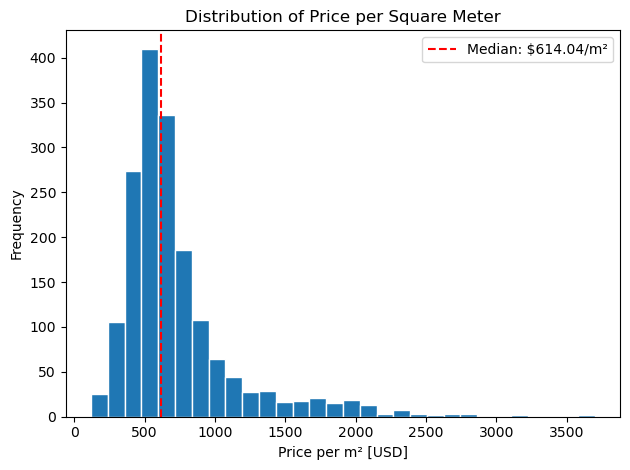

In [4]:
# Create figure and axes
fig, ax = plt.subplots()

# Create histogram with 30 bins
ax.hist(df["price_per_m2"], bins=30, edgecolor="white")

# Set labels and title
ax.set_title("Distribution of Price per Square Meter")
ax.set_xlabel("Price per m² [USD]")
ax.set_ylabel("Frequency")

# Add a vertical line for the median
median_price_per_m2 = df["price_per_m2"].median()
ax.axvline(median_price_per_m2, color='red', linestyle='--', 
           label=f'Median: ${median_price_per_m2:.2f}/m²')
ax.legend()

plt.tight_layout()
plt.show()

In [5]:
# Calculate statistics by state
state_price_stats = (
    df
    .groupby("state")
    ["price_per_m2"]                    # <--- "price_per_m2"
    .agg(['mean', 'median', 'std'])
    .sort_values(by='median', ascending=False)
    
    # Round to 2 decimal places for readability
    .round(2)
)


print("Price per m2 Statistics by State:")
state_price_stats

Price per m2 Statistics by State:


,mean,median,std
state,,,
Distrito Federal,1175.89,958.89,651.13
Guerrero,761.56,715.03,270.52
Quintana Roo,736.46,707.91,265.71
Oaxaca,683.02,683.02,196.87
Estado de México,763.75,674.30,396.69
Campeche,601.29,654.74,157.02
Nayarit,599.29,651.38,196.19
Querétaro,687.23,644.17,230.29
Jalisco,743.57,641.55,370.42


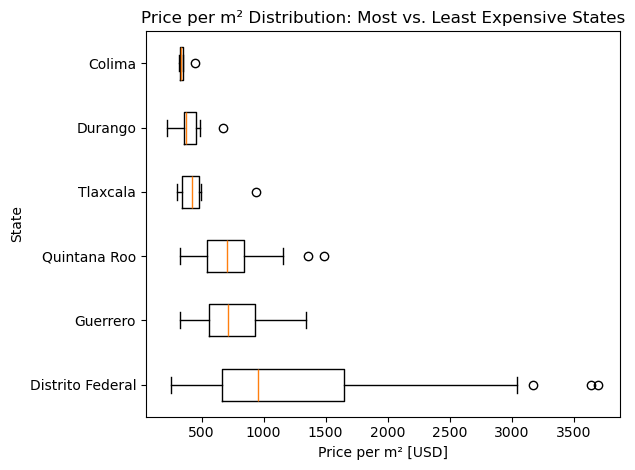

In [6]:
# 1. Identify the states we want to plot (Top 3 and Bottom 3)
top_states = state_price_stats.head(3).index.tolist()
bottom_states = state_price_stats.tail(3).index.tolist()
target_states = top_states + bottom_states

# 2. Filter data by target_states
df_states = df[df["state"].isin(target_states)]

# 3. Prepare data for plotting
# Create a list of arrays, one for each state in our target list
data_to_plot = [df_states[df_states["state"] == state]["price_per_m2"] 
                for state in target_states]

# 4. Plot
fig, ax = plt.subplots()

ax.boxplot(data_to_plot, tick_labels=target_states, vert=False)
ax.set_title("Price per m² Distribution: Most vs. Least Expensive States")
ax.set_xlabel("Price per m² [USD]")
ax.set_ylabel("State")

plt.tight_layout()
plt.show()


In [11]:
# 1. Correlation between size and price
size_price_correlation = df[["area_m2", "price_per_m2"]].corr().iloc[0, 1]
print(f"Correlation between area and price: {size_price_correlation:.3f}")

# 2. Calculate variance components
# Total variance in price_usd
total_variance = df["price_per_m2"].var()

# Between-state variance (variance of state_means)
state_means = df.groupby("state")["price_per_m2"].mean()
between_variance = state_means.var()

# Within-state variance (average variance within each state)
within_variance = df.groupby("state")["price_per_m2"].var().mean()

# 3. Calculate percentages
between_pct = (between_variance / total_variance) * 100
within_pct = (within_variance / total_variance) * 100

print(f"\nVariance Decomposition:")
print(f"  Between-state variance: {between_pct:.1f}%")
print(f"  Within-state variance: {within_pct:.1f}%")
print(f"  Ratio (Between/Within): {between_variance/within_variance:.2f}")

Correlation between area and price: -0.276

Variance Decomposition:
  Between-state variance: 12.3%
  Within-state variance: 38.5%
  Ratio (Between/Within): 0.32


Price per m² by Property Type:
                  mean  median  count
property_type                        
apartment      1138.51  958.89    407
house           609.40  570.77   1329


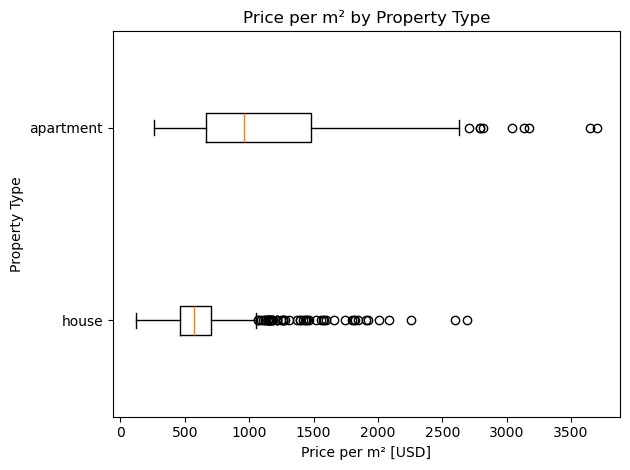

In [8]:
# 1. Calculate summary statistics by property_type
property_type_stats = (
    df
    .groupby("property_type")
    ["price_per_m2"]      #   <--- "price_per_m2"
    .agg(['mean', 'median', 'count'])
    .round(2)
)

print("Price per m² by Property Type:")
print(property_type_stats)

# 2. Get unique property types
prop_types = df["property_type"].unique()

# 3. Prepare data list
data_by_type = [df[df["property_type"] == p_type]["price_per_m2"] 
                for p_type in prop_types]

# 4. Plot
fig, ax = plt.subplots()

ax.boxplot(data_by_type, tick_labels=prop_types, vert=False)
ax.set_title("Price per m² by Property Type")
ax.set_xlabel("Price per m² [USD]")
ax.set_ylabel("Property Type")

plt.tight_layout()
plt.show()

In [9]:
# 1. Group by both state and property_type
combined_stats = (
    df
    .groupby(["state", "property_type"])   # <-- "state" and "property_type"
    ["price_per_m2"]      
    .agg(['median', 'count'])
    .round(2)
)

# 2. Filter for groups with at least 5 properties
combined_stats_filtered = combined_stats[combined_stats['count'] >= 5]

# 3. Sort by median price per m²
combined_stats_filtered = combined_stats_filtered.sort_values(
    by='median', ascending=False
)

print("Top 15 State-Property Type Combinations:")
display(combined_stats_filtered.head(15))

print("\nBottom 10 State-Property Type Combinations:")
combined_stats_filtered.tail(10)

Top 15 State-Property Type Combinations:


,,median,count
state,property_type,,
Nuevo León,apartment,1424.90,12
Jalisco,apartment,1288.66,8
Distrito Federal,apartment,1140.09,214
Quintana Roo,apartment,1003.79,11
Querétaro,apartment,1003.41,12
Estado de México,apartment,969.18,27
Puebla,apartment,960.88,22
Veracruz de Ignacio de la Llave,apartment,818.62,10
Yucatán,apartment,799.68,21



Bottom 10 State-Property Type Combinations:


,,median,count
state,property_type,,
Hidalgo,house,526.86,17
San Luis Potosí,house,493.82,45
Sonora,house,486.06,12
Sinaloa,house,482.46,23
Yucatán,house,481.21,150
Veracruz de Ignacio de la Llave,house,474.18,107
Aguascalientes,house,436.44,10
Tlaxcala,house,424.56,6
Durango,house,372.30,6


In [10]:
# Variance decomposition on price_per_m2 (not price_usd)
total_variance = df["price_per_m2"].var()
state_means = df.groupby("state")["price_per_m2"].mean()
between_variance = state_means.var()
within_variance = df.groupby("state")["price_per_m2"].var().mean()

between_pct = (between_variance / total_variance) * 100
within_pct = (within_variance / total_variance) * 100

print(f"Between-state variance: {between_pct:.1f}%")
print(f"Within-state variance: {within_pct:.1f}%")
print(f"Ratio (Between/Within): {between_variance/within_variance:.2f}")

Between-state variance: 12.3%
Within-state variance: 38.5%
Ratio (Between/Within): 0.32
